# <center> Предсказание победителя в Dota 2
<center> <img src="https://248006.selcdn.ru/main/iblock/d52/d523440eddffa606bcf4e78a5011a822/2ef90fdbc3e9306a45851dca974be243.jpg" width="700" height="700">

[Почитать подбробнее](https://meduza.io/feature/2021/10/19/rossiyskaya-komanda-vyigrala-chempionat-mira-po-dota-2-i-poluchila-18-millionov-dollarov-postoyte-otkuda-takie-dengi-neuzheli-igrat-v-dotu-tak-slozhno)

#### [Оригинальная статья](https://arxiv.org/pdf/2106.01782.pdf)
    
### Начало

Посмотрим на готовые признаки и сделаем первую посылку.

1. [Описание данных](#Описание-данных)
2. [Описание признаков](#Описание-признаков)
3. [Наша первая модель](#Наша-первая-модель)
4. [Посылка](#Посылка)

### Первые шаги на пути в датасайенс

5. [Кросс-валидация](#Кросс-валидация)
6. [Что есть в json файлах?](#Что-есть-в-json-файлах?)
7. [Feature engineering](#Feature-engineering)

### Импорты

In [47]:
import os
import json
import pandas as pd
import datetime
import warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

%matplotlib inline

In [48]:
SEED = 10801
sns.set_style(style="whitegrid")
plt.rcParams["figure.figsize"] = 12, 8
warnings.filterwarnings("ignore")

## <left>Описание данных

Файлы:

- `sample_submission.csv`: пример файла-посылки
- `train_raw_data.jsonl`, `test_raw_data.jsonl`: "сырые" данные
- `train_data.csv`, `test_data.csv`: признаки, созданные авторами
- `train_targets.csv`: результаты тренировочных игр

## <left>Описание признаков
    
Набор простых признаков, описывающих игроков и команды в целом

In [49]:
PATH_TO_DATA = "/kaggle/input/copy-of-23-24-ml/"

df_train_features = pd.read_csv(os.path.join(PATH_TO_DATA,
                                             "train_data.csv"),
                                    index_col="match_id_hash")
df_train_targets = pd.read_csv(os.path.join(PATH_TO_DATA,
                                            "train_targets.csv"),
                                   index_col="match_id_hash")

In [50]:
df_train_features.shape

(31698, 245)

In [51]:
df_train_features.head()

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,...,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed
match_id_hash,,,,,,,,,,,,,,,,,,,,,
b9c57c450ce74a2af79c9ce96fac144d,658,4,0,3,10,15,7,2,0,7,...,0.000000,0,0,0,0,0.00,0,0,0,0
6db558535151ea18ca70a6892197db41,21,23,0,0,0,101,0,0,0,0,...,0.000000,0,0,0,0,0.00,0,0,0,0
19c39fe2af2b547e48708ca005c6ae74,160,22,7,0,0,57,0,0,0,1,...,0.000000,0,0,0,0,0.00,0,0,0,0
c96d629dc0c39f0c616d1949938a6ba6,1016,22,0,1,0,119,0,3,3,5,...,8.264696,0,0,3,0,0.25,0,0,3,0
156c88bff4e9c4668b0f53df3d870f1b,582,22,7,2,2,12,3,1,2,9,...,15.762911,3,1,0,1,0.50,0,0,3,0


Имеем ~32 тысячи наблюдений, каждое из которых характеризуется уникальным `match_id_hash` (захэшированное id матча), и 245 признаков. `game_time` показывает момент времени, в который получены эти данные. То есть по сути это не длительность самого матча, а например, его середина, таким образом, в итоге мы сможем получить модель, которая будет предсказывать вероятность победы каждой из команд в течение матча (хорошо подходит для букмекеров).

Нас интересует поле `radiant_win` (так называется одна из команд, вторая - dire). Остальные колоки здесь по сути получены из "будущего" и есть только для тренировочных данных, поэтому на них можно просто посмотреть).

In [52]:
df_train_targets.head()

,game_time,radiant_win,duration,time_remaining,next_roshan_team
match_id_hash,,,,,
b9c57c450ce74a2af79c9ce96fac144d,658,True,1154,496,NaN
6db558535151ea18ca70a6892197db41,21,True,1503,1482,Radiant
19c39fe2af2b547e48708ca005c6ae74,160,False,2063,1903,NaN
c96d629dc0c39f0c616d1949938a6ba6,1016,True,2147,1131,Radiant
156c88bff4e9c4668b0f53df3d870f1b,582,False,1927,1345,Dire


## <left>Наша первая модель

In [53]:
X = df_train_features.values
y = df_train_targets["radiant_win"].values.astype("int8")

In [54]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y,
                                                      test_size=0.3,
                                                      random_state=SEED)

#### Обучим случайный лес

In [55]:
%%time
rf_model = RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)
rf_model.fit(X_train, y_train)

CPU times: user 40.3 s, sys: 186 ms, total: 40.5 s
Wall time: 10.6 s


RandomForestClassifier(max_depth=7, n_estimators=300, n_jobs=-1,
                       random_state=10801)

#### Сделаем предсказания и оценим качество на отложенной части данных

In [56]:
y_pred = rf_model.predict_proba(X_valid)[:, 1]

In [57]:
valid_score = roc_auc_score(y_valid, y_pred)
print("ROC-AUC score на отложенной части:", valid_score)

ROC-AUC score на отложенной части: 0.7754387258058622


Посмотрим на accuracy:

In [58]:
valid_accuracy = accuracy_score(y_valid, y_pred > 0.5)
print("Accuracy score (p > 0.5) на отложенной части:", valid_accuracy)

Accuracy score (p > 0.5) на отложенной части: 0.6885383806519453


## <left>Посылка

In [ ]:
df_test_features = pd.read_csv(os.path.join(PATH_TO_DATA, "test_data.csv"),
                                   index_col="match_id_hash")

X_test = df_test_features.values
y_test_pred = rf_model.predict_proba(X_test)[:, 1]

df_submission = pd.DataFrame({"radiant_win_prob": y_test_pred},
                                 index=df_test_features.index)

In [ ]:
submission_filename = "submission_{}.csv".format(
    datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
df_submission.to_csv(submission_filename)
print("Файл посылки сохранен, как: {}".format(submission_filename))

## <left>Кросс-валидация

Во многих случаях кросс-валидация оказывается лучше простого разбиения на test и train. Воспользуемся `ShuffleSplit` чтобы создать 5 70%/30% наборов данных.

In [59]:
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=SEED)

In [60]:
%%time
rf_model = RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc")

CPU times: user 3min 26s, sys: 868 ms, total: 3min 26s
Wall time: 55.8 s


In [61]:
cv_scores_rf

array([0.77543873, 0.77343884, 0.76649967, 0.7722681 , 0.77246001])

In [62]:
print(f"Среднее значение ROC-AUC на кросс-валидации: {cv_scores_rf.mean()}")

Среднее значение ROC-AUC на кросс-валидации: 0.7720210676055513


Получилось, что без кросс-валидации ROC-AUC ~ 0.775. 
На кросс-валидации ~ 0.772 (т.е. чутка меньше). На каггле: 0.78639.

## <left>Что есть в json файлах?

Описание сырых данных можно найти в `train_matches.jsonl` и `test_matches.jsonl`. Каждый файл содержит одну запись для каждого матча в [JSON](https://en.wikipedia.org/wiki/JSON) формате. Его легко превратить в питоновский объект при помощи метода `json.loads`.

In [63]:
with open(os.path.join(PATH_TO_DATA, "train_raw_data.jsonl")) as fin:
    # прочтем 419 строку
    for i in range(419):
        line = fin.readline()

    # переведем JSON в питоновский словарь
    match = json.loads(line)

In [57]:
match

{'game_time': 2049,
 'match_id_hash': '75112757bde649d5cff1c7cd4f1275c6',
 'teamfights': [{'start': 306.755,
   'end': 338.551,
   'last_death': 323.454,
   'deaths': 3,
   'players': [{'deaths_pos': {},
     'ability_uses': {'lich_frost_nova': 2, 'lich_dark_ritual': 1},
     'item_uses': {},
     'killed': {'npc_dota_hero_faceless_void': 114},
     'deaths': 0,
     'buybacks': 0,
     'damage': 383,
     'healing': 0,
     'gold_delta': 336,
     'xp_delta': 440},
    {'deaths_pos': {},
     'ability_uses': {'pudge_meat_hook': 1, 'pudge_rot': 1},
     'item_uses': {'smoke_of_deceit': 1, 'tpscroll': 1},
     'killed': {},
     'deaths': 0,
     'buybacks': 0,
     'damage': 458,
     'healing': 0,
     'gold_delta': -10,
     'xp_delta': 76},
    {'deaths_pos': {},
     'ability_uses': {},
     'item_uses': {},
     'killed': {},
     'deaths': 0,
     'buybacks': 0,
     'damage': 0,
     'healing': 0,
     'gold_delta': 174,
     'xp_delta': 249},
    {'deaths_pos': {},
     'abilit

In [64]:
player = match["players"][9]
player["kills"], player["deaths"], player["assists"]
#для KDA будем юзать

(0, 5, 5)

In [65]:
(player["kills"] + player["deaths"])/player["assists"]#но только assists мб 0. так что там ниже прибавим в знаменатель 1

1.0

In [47]:
player

{'player_slot': 132,
 'hero_id': 83,
 'hero_name': 'npc_dota_hero_treant',
 'account_id_hash': '116aa09d7684da7a6bc388276b1abd1a',
 'ability_upgrades': [{'ability': 5434, 'time': 285, 'level': 1},
  {'ability': 5436, 'time': 488, 'level': 2},
  {'ability': 5436, 'time': 672, 'level': 3},
  {'ability': 5435, 'time': 913, 'level': 4},
  {'ability': 5437, 'time': 1144, 'level': 5},
  {'ability': 5436, 'time': 1145, 'level': 6},
  {'ability': 5436, 'time': 1360, 'level': 7},
  {'ability': 5435, 'time': 1527, 'level': 8},
  {'ability': 5435, 'time': 1660, 'level': 9},
  {'ability': 6024, 'time': 1687, 'level': 10},
  {'ability': 5435, 'time': 1916, 'level': 11}],
 'obs_placed': 8,
 'sen_placed': 0,
 'creeps_stacked': 0,
 'camps_stacked': 0,
 'rune_pickups': 17,
 'firstblood_claimed': 0,
 'teamfight_participation': 0.217,
 'towers_killed': 0,
 'roshans_killed': 0,
 'observers_placed': 8,
 'stuns': 33.337,
 'max_hero_hit': {'type': 'max_hero_hit',
  'time': 2010.079,
  'max': True,
  'inflict

KDA - может быть неплохим признаком, этот показатель считается как:
    
<center>$KDA = \frac{K + A}{D}$

Информация о количестве использованных способностей:

In [66]:
player["ability_uses"]#они ж все разные для разных персонажей

{'treant_living_armor': 52, 'treant_leech_seed': 5, 'treant_overgrowth': 5}

In [67]:
player["hero_id"]#герои кодируются цифрами, но по смыслу это категория

83

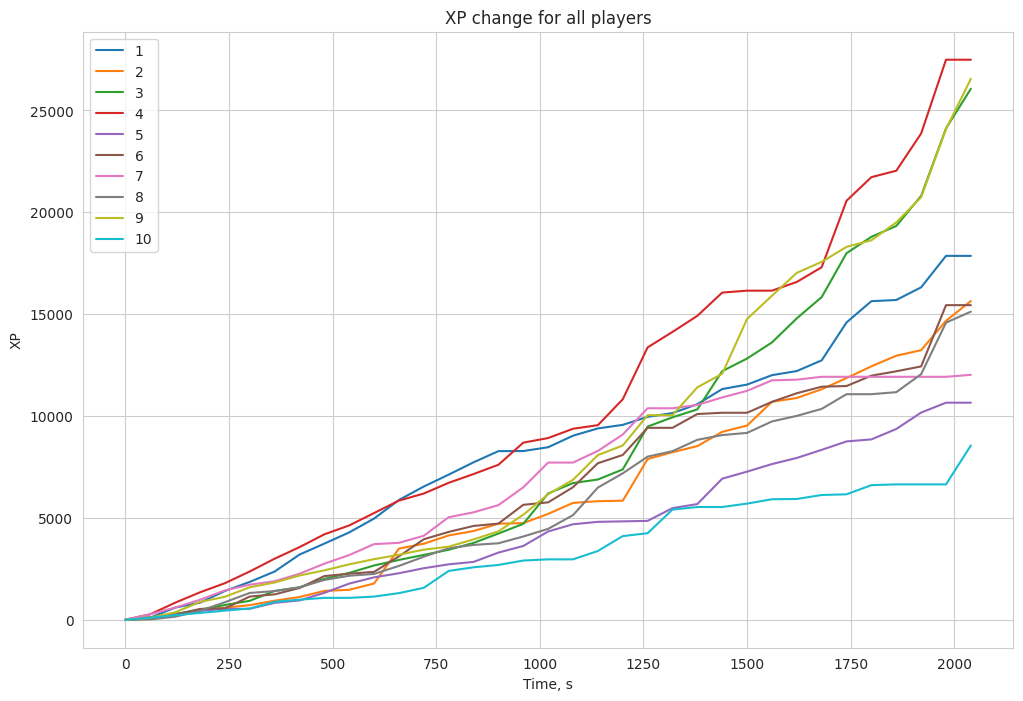

In [69]:
for i, player in enumerate(match["players"]):
    plt.plot(player["times"], player["xp_t"], label=str(i+1))

plt.legend()
plt.xlabel("Time, s")
plt.ylabel("XP")
plt.title("XP change for all players");

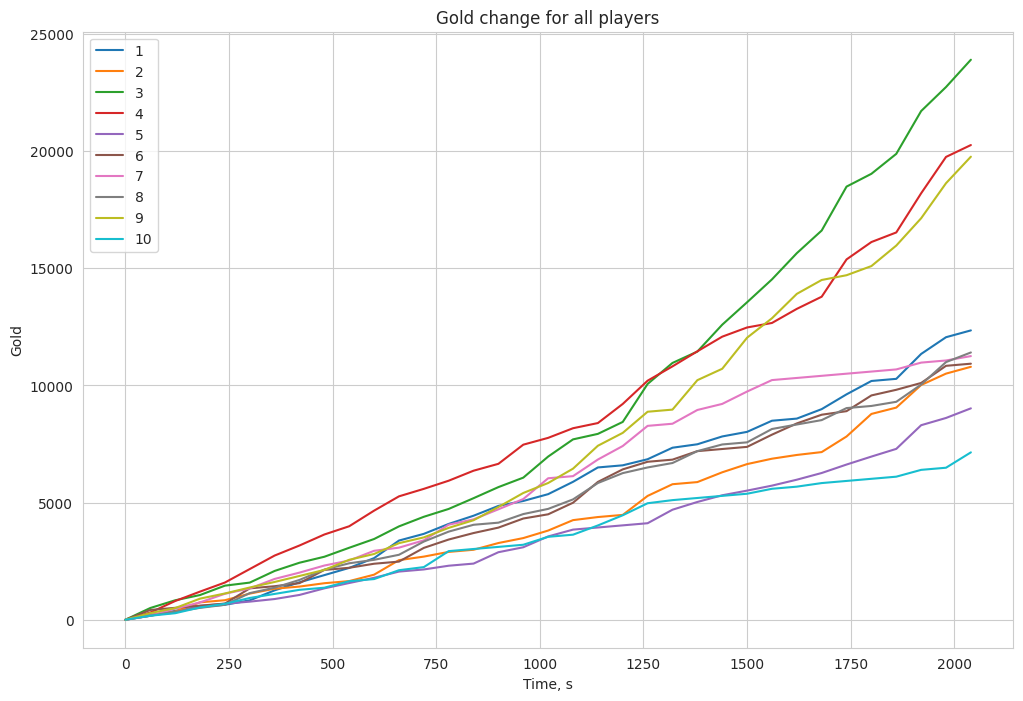

In [70]:
#ради интереса ещё на голду глянем
for i, player in enumerate(match["players"]):
    plt.plot(player["times"], player["gold_t"], label=str(i+1))

plt.legend()
plt.xlabel("Time, s")
plt.ylabel("Gold")
plt.title("Gold change for all players");
#ну кстати по голже 3ий вытянул, а по хп красный, но они все r

#### Сделаем чтение файла с сырыми данными и добавление новых признаков удобным

В этот раз для чтение `json` файлов лучше использовать библиотеку `ujson`, иначе все будет слишком долго :(

In [71]:
try:
    import ujson as json
except ModuleNotFoundError:
    import json
    print ("Подумайте об установке ujson, чтобы работать с JSON объектами быстрее")

try:
    from tqdm.notebook import tqdm
except ModuleNotFoundError:
    tqdm_notebook = lambda x: x
    print ("Подумайте об установке tqdm, чтобы следить за прогрессом")


def read_matches(matches_file, total_matches=31698, n_matches_to_read=None):
    """
    Аргумент
    -------
    matches_file: JSON файл с сырыми данными

    Результат
    ---------
    Возвращает записи о каждом матче
    """

    if n_matches_to_read is None:
        n_matches_to_read = total_matches

    c = 0
    with open(matches_file) as fin:
        for line in tqdm(fin, total=total_matches):
            if c >= n_matches_to_read:
                break
            else:
                c += 1
                yield json.loads(line)

#### Чтение данных в цикле

Чтение всех данных занимает 1-2 минуты, поэтому для начала можно попробовать следующее:

1. Читать 10-50 игр
2. Написать код для работы с этими JSON объектами
3. Убедиться, что все работает
4. Запустить код на всем датасете
5. Сохранить результат в `pickle` файл, чтобы в следующий раз не переделывать все заново

## <left>Feature engineering

Напишем функцию, которая поможет нам легче добавлять новые признаки.

In [29]:
def add_new_features(df_features, matches_file):
    """
    Аргументы
    -------
    df_features: таблица с данными
    matches_file: JSON файл с сырыми данными

    Результат
    ---------
    Добавляет новые признаки в таблицу
    """

    for match in read_matches(matches_file):
        match_id_hash = match['match_id_hash']
        
        
        #--------вторая версия модели--------

        # Посчитаем количество разрушенных вышек обеими командами
        radiant_tower_kills = 0
        dire_tower_kills = 0
        for objective in match["objectives"]:
            if objective["type"] == "CHAT_MESSAGE_TOWER_KILL":
                if objective["team"] == 2:
                    radiant_tower_kills += 1
                if objective["team"] == 3:
                    dire_tower_kills += 1

        df_features.loc[match_id_hash, "radiant_tower_kills"] = radiant_tower_kills
        df_features.loc[match_id_hash, "dire_tower_kills"] = dire_tower_kills
        df_features.loc[match_id_hash, "diff_tower_kills"] = radiant_tower_kills - dire_tower_kills
        #только с этими признаками на кросс-валидации ~0.779

        # ... (/¯◡ ‿ ◡)/¯☆*:・ﾟ добавляем новые признаки ...
        
        
        #--------третья версия модели (сначала обсужденные ранее)--------
        
        #KDA (по идее KDA рассчитывается для каждого отдельного игрока, но ход командного матча всё-таки определяется всеми учасниками команды (даже если один плохо играет, то соратники могут вытянуть),так что давайте считать для каждой команды в матче общий)
        KDAs = []
        for player in match["players"]:
            KDAs.append((player["kills"] + player["assists"])/(player["deaths"] + 1))        
        
        df_features.loc[match_id_hash, "radiant_KDA"] = sum(KDAs[0:5])
        df_features.loc[match_id_hash, "dire_KDA"] = sum(KDAs[5:10])
        #с этими и предыдущими признаками на кросс-валидации ~0.787
        
        #использованные способности (давайте опять-таки просуммируем для всех игроков (из соображений, что чем больше значение, тем значимее она в игре))
        match_ability_score = []
        for player in match["players"]:
            player_ability_score = 0
            for score in player["ability_uses"].values():
                player_ability_score += score
            match_ability_score.append(player_ability_score)      
        
        df_features.loc[match_id_hash, "radiant_ability_uses"] = sum(match_ability_score[0:5])
        df_features.loc[match_id_hash, "dire_ability_uses"] = sum(match_ability_score[5:10])
        #с этими и предыдущими признаками на кросс-валидации ~0.787
        
        #давайте с xp_t поколдуем: будем брать производную, друзья (просто интересно что с такой динамической штукой получится)
        xp_t_ds = []
        for player in match["players"]:
            times = player["times"]
            xp_t_s = player["xp_t"]
            xp_t_d = 0
            for i in range(0, len(times)-1):
                xp_t_d += (xp_t_s[i+1] - xp_t_s[i]) / (times[i+1] - times[i])
            xp_t_ds.append(xp_t_d)
        
        df_features.loc[match_id_hash, "radiant_hp_td"] = sum(xp_t_ds[0:5])#тут я написала hp, но это xp, но заметила уже в конце (проблемы русско/английского восприятия)
        df_features.loc[match_id_hash, "dire_hp_td"] = sum(xp_t_ds[5:10])
        #с этими и предыдущими признаками на кросс-валидации ~0.787
        
        #крч лучше не становится (давайте глянем ниже какие в принципе признаки модельке нравятся)

In [72]:
# Скопируем таблицу с признаками
df_train_features_extended = df_train_features.copy()

# Добавим новые
add_new_features(df_train_features_extended,
                 os.path.join(PATH_TO_DATA,
                              "train_raw_data.jsonl"))

  0%|          | 0/31698 [00:00<?, ?it/s]

In [73]:
df_train_features_extended.head()

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,...,d5_sen_placed,radiant_tower_kills,dire_tower_kills,diff_tower_kills,radiant_KDA,dire_KDA,radiant_ability_uses,dire_ability_uses,radiant_hp_td,dire_hp_td
match_id_hash,,,,,,,,,,,,,,,,,,,,,
b9c57c450ce74a2af79c9ce96fac144d,658,4,0,3,10,15,7,2,0,7,...,0,2.0,0.0,2.0,20.333333,1.476190,94.0,102.0,269.516667,184.500000
6db558535151ea18ca70a6892197db41,21,23,0,0,0,101,0,0,0,0,...,0,0.0,0.0,0.0,0.000000,0.000000,1.0,1.0,0.000000,0.000000
19c39fe2af2b547e48708ca005c6ae74,160,22,7,0,0,57,0,0,0,1,...,0,0.0,0.0,0.0,0.000000,0.000000,10.0,4.0,32.366667,30.650000
c96d629dc0c39f0c616d1949938a6ba6,1016,22,0,1,0,119,0,3,3,5,...,0,0.0,0.0,0.0,6.416667,10.133333,186.0,161.0,407.083333,411.866667
156c88bff4e9c4668b0f53df3d870f1b,582,22,7,2,2,12,3,1,2,9,...,0,0.0,1.0,-1.0,5.428571,11.333333,140.0,61.0,188.500000,208.133333


In [74]:
%%time
rf_model_ext = RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)#давайте разделим базовую и с новыми признаками
#rf_model_ext.fit(X_train, y_train)

cv_scores_base = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
cv_scores_extended = cross_val_score(rf_model_ext, df_train_features_extended.values, y,
                                     cv=cv, scoring="roc_auc", n_jobs=-1)

CPU times: user 650 ms, sys: 362 ms, total: 1.01 s
Wall time: 1min 59s


In [75]:
print(f"ROC-AUC на кросс-валидации для базовых признаков: {cv_scores_base.mean()}")
print(f"ROC-AUC на кросс-валидации для новых признаков: {cv_scores_extended.mean()}")

ROC-AUC на кросс-валидации для базовых признаков: 0.7720210676055513
ROC-AUC на кросс-валидации для новых признаков: 0.7871911791201274


Видно, что случайный лес стал работать немного лучше при добавлении новых признаков (0.7720210676055513 -> 0.7871911791201274). A еще нужно, наверное, как-то по-умному закодировать категориальные признаки.

Дальше дело за малым. Добавляйте новые признаки, пробуйте другие методы, которые мы изучили, а также что-то интересное, что мы не прошли. Удачи!

In [35]:
# обновим посылку в варианте extended

#для теста нужно добавить те же новые фичи
df_test_features_extended = pd.read_csv(os.path.join(PATH_TO_DATA, "test_data.csv"),
                                   index_col="match_id_hash")#df_test_features.copy()
add_new_features(df_test_features_extended, 
                 os.path.join(PATH_TO_DATA, 
                              "test_raw_data.jsonl"))
#полоса доходит до 7977 (это столько в тесте матчей, так что всё норм с полосой загрузки)

  0%|          | 0/31698 [00:00<?, ?it/s]

In [76]:
df_test_features_extended.head()#проверяем, что всё правильно

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,...,d5_sen_placed,radiant_tower_kills,dire_tower_kills,diff_tower_kills,radiant_KDA,dire_KDA,radiant_ability_uses,dire_ability_uses,radiant_hp_td,dire_hp_td
match_id_hash,,,,,,,,,,,,,,,,,,,,,
a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,...,0,0.0,0.0,0.0,0.000000,2.000000,7.0,11.0,21.950000,34.166667
46a0ddce8f7ed2a8d9bd5edcbb925682,576,22,7,1,4,14,1,0,3,1,...,0,0.0,0.0,0.0,10.500000,0.750000,115.0,82.0,230.166667,184.783333
b1b35ff97723d9b7ade1c9c3cf48f770,453,22,7,1,3,42,0,1,1,0,...,0,0.0,0.0,0.0,3.833333,4.500000,87.0,70.0,141.916667,164.350000
ab3cc6ccac661a1385e73a2e9f21313a,721,4,0,2,1,30,2,2,1,3,...,0,1.0,0.0,1.0,4.833333,10.500000,229.0,101.0,294.183333,275.350000
54aaab1cb8cc5df3c253641618673266,752,22,7,1,0,8,2,0,2,8,...,0,0.0,0.0,0.0,10.000000,1.916667,155.0,162.0,322.533333,302.133333


In [77]:
df_test_features_extended.columns[10:50]

Index(['r1_gold', 'r1_lh', 'r1_xp', 'r1_health', 'r1_max_health',
       'r1_max_mana', 'r1_level', 'r1_x', 'r1_y', 'r1_stuns',
       'r1_creeps_stacked', 'r1_camps_stacked', 'r1_rune_pickups',
       'r1_firstblood_claimed', 'r1_teamfight_participation',
       'r1_towers_killed', 'r1_roshans_killed', 'r1_obs_placed',
       'r1_sen_placed', 'r2_hero_id', 'r2_kills', 'r2_deaths', 'r2_assists',
       'r2_denies', 'r2_gold', 'r2_lh', 'r2_xp', 'r2_health', 'r2_max_health',
       'r2_max_mana', 'r2_level', 'r2_x', 'r2_y', 'r2_stuns',
       'r2_creeps_stacked', 'r2_camps_stacked', 'r2_rune_pickups',
       'r2_firstblood_claimed', 'r2_teamfight_participation',
       'r2_towers_killed'],
      dtype='object')

In [78]:
#теперь моделька
rf_model_ext.fit(df_train_features_extended.values, y)
X_test = df_test_features_extended.values
y_test_pred = rf_model_ext.predict_proba(X_test)[:, 1]

In [131]:
#сама посылка
df_submission_extended = pd.DataFrame({"radiant_win_prob": y_test_pred},
                                 index=df_test_features_extended.index)

submission_filename = "submission_{}.csv".format(
    datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
df_submission_extended.to_csv(submission_filename)
print("Файл посылки сохранен, как: {}".format(submission_filename))

Файл посылки сохранен, как: submission_2024-04-02_16-17-57.csv


In [80]:
#давайте глянем, какие фичи оказались полезными:
feature_scores = pd.Series(rf_model_ext.feature_importances_, index=df_train_features_extended.columns).sort_values(ascending=False)

feature_scores #ну кстати новые фичи не на самом дне (приятно). А так важны вышки, KDA, что логично

diff_tower_kills         0.109473
dire_KDA                 0.103508
radiant_KDA              0.099670
dire_tower_kills         0.037801
radiant_tower_kills      0.034659
                           ...   
d1_roshans_killed        0.000038
d2_firstblood_claimed    0.000033
d5_firstblood_claimed    0.000030
lobby_type               0.000028
r3_firstblood_claimed    0.000004
Length: 254, dtype: float64

In [41]:
#топ 10
feature_scores[0:10]#неоижанно, что x и y важны. 

diff_tower_kills       0.109473
dire_KDA               0.103508
radiant_KDA            0.099670
dire_tower_kills       0.037801
radiant_tower_kills    0.034659
d4_x                   0.020176
r4_y                   0.017394
d1_x                   0.017131
r5_x                   0.017101
r5_y                   0.016759
dtype: float64

# ----- Здесь закончилась основная часть -----

# EDA

Давайте чутка повнимательнее посмотрим, что мы тут наколдовали

In [275]:
#сколько чего (уже смотрели выше, но пусть всё будет в одном месте)
print(f'Строк {df_train_features_extended.shape[0]} и колонок {df_train_features_extended.shape[1]}')

Строк 31698 и колонок 254


In [276]:
#Изучим датафрейм
df_train_features_extended.info(verbose=True)
#всё числовое

<class 'pandas.core.frame.DataFrame'>
Index: 31698 entries, b9c57c450ce74a2af79c9ce96fac144d to e2ca68ac1a6847f4a37f6c9c8ee8695b
Data columns (total 254 columns):
 #    Column                      Dtype  
---   ------                      -----  
 0    game_time                   int64  
 1    game_mode                   int64  
 2    lobby_type                  int64  
 3    objectives_len              int64  
 4    chat_len                    int64  
 5    r1_hero_id                  int64  
 6    r1_kills                    int64  
 7    r1_deaths                   int64  
 8    r1_assists                  int64  
 9    r1_denies                   int64  
 10   r1_gold                     int64  
 11   r1_lh                       int64  
 12   r1_xp                       int64  
 13   r1_health                   int64  
 14   r1_max_health               int64  
 15   r1_max_mana                 float64
 16   r1_level                    int64  
 17   r1_x                        int64

In [278]:
#глянем все признаки
print(list(df_train_features_extended.columns))#просто список всех фичей

['game_time', 'game_mode', 'lobby_type', 'objectives_len', 'chat_len', 'r1_hero_id', 'r1_kills', 'r1_deaths', 'r1_assists', 'r1_denies', 'r1_gold', 'r1_lh', 'r1_xp', 'r1_health', 'r1_max_health', 'r1_max_mana', 'r1_level', 'r1_x', 'r1_y', 'r1_stuns', 'r1_creeps_stacked', 'r1_camps_stacked', 'r1_rune_pickups', 'r1_firstblood_claimed', 'r1_teamfight_participation', 'r1_towers_killed', 'r1_roshans_killed', 'r1_obs_placed', 'r1_sen_placed', 'r2_hero_id', 'r2_kills', 'r2_deaths', 'r2_assists', 'r2_denies', 'r2_gold', 'r2_lh', 'r2_xp', 'r2_health', 'r2_max_health', 'r2_max_mana', 'r2_level', 'r2_x', 'r2_y', 'r2_stuns', 'r2_creeps_stacked', 'r2_camps_stacked', 'r2_rune_pickups', 'r2_firstblood_claimed', 'r2_teamfight_participation', 'r2_towers_killed', 'r2_roshans_killed', 'r2_obs_placed', 'r2_sen_placed', 'r3_hero_id', 'r3_kills', 'r3_deaths', 'r3_assists', 'r3_denies', 'r3_gold', 'r3_lh', 'r3_xp', 'r3_health', 'r3_max_health', 'r3_max_mana', 'r3_level', 'r3_x', 'r3_y', 'r3_stuns', 'r3_creep

In [279]:
#посмотрим уникальные (чтобы потом выбирать категориальные фичи)
cols = list(df_train_features_extended.columns)
nuniq = list(df_train_features_extended.nunique())

nu_df = pd.DataFrame({'feature': cols, 'uniq_val': nuniq})
nu_df[0:50]

,feature,uniq_val
0,game_time,3314
1,game_mode,8
2,lobby_type,2
3,objectives_len,41
4,chat_len,152
5,r1_hero_id,115
6,r1_kills,33
7,r1_deaths,25
8,r1_assists,40
9,r1_denies,68


Давайте выберем такие Категориальные (индекс-название-сколько уникальных): 
* 1	game_mode	8
* 2	lobby_type	2
* 5	r1_hero_id	115
* 29	r2_hero_id	115
* 53	r3_hero_id	115
* 77	r4_hero_id	115
* 101	r5_hero_id	115
* 125	d1_hero_id	115
* 149	d2_hero_id	115
* 173	d3_hero_id	115
* 197	d4_hero_id	115
* 221	d5_hero_id	115

Пояснение: тут в целом названия сами за себя говорят mode и type + айдишник героя (по сути какой перс)

In [280]:
#Краткая сводка
df_train_features_extended.describe()
#данные не стандартизированы, но нам это и не нужно пока

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,...,d5_sen_placed,radiant_tower_kills,dire_tower_kills,diff_tower_kills,radiant_KDA,dire_KDA,radiant_ability_uses,dire_ability_uses,radiant_hp_td,dire_hp_td
count,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,...,31698.000000,31698.000000,31698.000000,31698.00000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000
mean,1146.519496,19.583538,4.771563,6.535239,7.358982,51.081614,3.151713,3.273361,4.661998,6.255600,...,0.780933,2.193545,1.980346,0.21320,9.741998,9.766134,330.375450,334.947094,668.039828,671.097524
std,766.936655,6.306635,3.260899,6.486933,13.295763,34.573173,3.727116,3.281208,5.207887,8.144267,...,2.436478,2.567384,2.495557,2.67417,7.424689,7.523067,430.150165,440.778588,578.693053,586.195971
min,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-11.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,521.000000,22.000000,0.000000,1.000000,0.000000,20.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,-1.00000,4.450198,4.333333,89.000000,89.000000,195.491667,193.220833
50%,1044.000000,22.000000,7.000000,4.000000,3.000000,44.000000,2.000000,2.000000,3.000000,3.000000,...,0.000000,1.000000,1.000000,0.00000,8.655952,8.566667,225.000000,226.000000,500.816667,496.733333
75%,1659.000000,22.000000,7.000000,10.000000,9.000000,81.000000,5.000000,5.000000,7.000000,9.000000,...,0.000000,4.000000,3.000000,1.00000,13.428571,13.574794,420.000000,422.000000,1010.933333,1020.787500
max,4933.000000,23.000000,7.000000,43.000000,291.000000,120.000000,32.000000,27.000000,40.000000,83.000000,...,47.000000,11.000000,11.000000,11.00000,81.904762,65.338889,7879.000000,7727.000000,2449.933333,2356.350000


In [281]:
#Кол-во NA
print(f'Количество NA: {(df_train_features_extended.isnull().sum()).sum()}')
#Дубликаты
print(f'Количество дубликатов: {(df_train_features_extended[df_train_features_extended.duplicated()]).shape[0]}')
#Тут всё хорошо, ничего чистить и править не надо

Количество NA: 0
Количество дубликатов: 0


In [286]:
print(list(df_train_features_extended.columns))

['game_time', 'game_mode', 'lobby_type', 'objectives_len', 'chat_len', 'r1_hero_id', 'r1_kills', 'r1_deaths', 'r1_assists', 'r1_denies', 'r1_gold', 'r1_lh', 'r1_xp', 'r1_health', 'r1_max_health', 'r1_max_mana', 'r1_level', 'r1_x', 'r1_y', 'r1_stuns', 'r1_creeps_stacked', 'r1_camps_stacked', 'r1_rune_pickups', 'r1_firstblood_claimed', 'r1_teamfight_participation', 'r1_towers_killed', 'r1_roshans_killed', 'r1_obs_placed', 'r1_sen_placed', 'r2_hero_id', 'r2_kills', 'r2_deaths', 'r2_assists', 'r2_denies', 'r2_gold', 'r2_lh', 'r2_xp', 'r2_health', 'r2_max_health', 'r2_max_mana', 'r2_level', 'r2_x', 'r2_y', 'r2_stuns', 'r2_creeps_stacked', 'r2_camps_stacked', 'r2_rune_pickups', 'r2_firstblood_claimed', 'r2_teamfight_participation', 'r2_towers_killed', 'r2_roshans_killed', 'r2_obs_placed', 'r2_sen_placed', 'r3_hero_id', 'r3_kills', 'r3_deaths', 'r3_assists', 'r3_denies', 'r3_gold', 'r3_lh', 'r3_xp', 'r3_health', 'r3_max_health', 'r3_max_mana', 'r3_level', 'r3_x', 'r3_y', 'r3_stuns', 'r3_creep

In [293]:
nu_df[120:140]

,feature,uniq_val
120,r5_teamfight_participation,767
121,r5_towers_killed,9
122,r5_roshans_killed,5
123,r5_obs_placed,26
124,r5_sen_placed,39
125,d1_hero_id,115
126,d1_kills,32
127,d1_deaths,28
128,d1_assists,39
129,d1_denies,72


In [301]:
list(df_train_features_extended.columns[0:125])

['game_time',
 'game_mode',
 'lobby_type',
 'objectives_len',
 'chat_len',
 'r1_hero_id',
 'r1_kills',
 'r1_deaths',
 'r1_assists',
 'r1_denies',
 'r1_gold',
 'r1_lh',
 'r1_xp',
 'r1_health',
 'r1_max_health',
 'r1_max_mana',
 'r1_level',
 'r1_x',
 'r1_y',
 'r1_stuns',
 'r1_creeps_stacked',
 'r1_camps_stacked',
 'r1_rune_pickups',
 'r1_firstblood_claimed',
 'r1_teamfight_participation',
 'r1_towers_killed',
 'r1_roshans_killed',
 'r1_obs_placed',
 'r1_sen_placed',
 'r2_hero_id',
 'r2_kills',
 'r2_deaths',
 'r2_assists',
 'r2_denies',
 'r2_gold',
 'r2_lh',
 'r2_xp',
 'r2_health',
 'r2_max_health',
 'r2_max_mana',
 'r2_level',
 'r2_x',
 'r2_y',
 'r2_stuns',
 'r2_creeps_stacked',
 'r2_camps_stacked',
 'r2_rune_pickups',
 'r2_firstblood_claimed',
 'r2_teamfight_participation',
 'r2_towers_killed',
 'r2_roshans_killed',
 'r2_obs_placed',
 'r2_sen_placed',
 'r3_hero_id',
 'r3_kills',
 'r3_deaths',
 'r3_assists',
 'r3_denies',
 'r3_gold',
 'r3_lh',
 'r3_xp',
 'r3_health',
 'r3_max_health',
 '

In [303]:
df_train_features_extended[list(df_train_features_extended.columns[0:125])]

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,...,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed
match_id_hash,,,,,,,,,,,,,,,,,,,,,
b9c57c450ce74a2af79c9ce96fac144d,658,4,0,3,10,15,7,2,0,7,...,21.697395,0,0,2,0,0.375000,1,0,0,0
6db558535151ea18ca70a6892197db41,21,23,0,0,0,101,0,0,0,0,...,0.000000,0,0,1,0,0.000000,0,0,0,0
19c39fe2af2b547e48708ca005c6ae74,160,22,7,0,0,57,0,0,0,1,...,4.132324,0,0,0,0,0.000000,0,0,1,0
c96d629dc0c39f0c616d1949938a6ba6,1016,22,0,1,0,119,0,3,3,5,...,9.730849,0,0,10,1,0.400000,0,0,0,0
156c88bff4e9c4668b0f53df3d870f1b,582,22,7,2,2,12,3,1,2,9,...,0.000000,0,0,3,0,0.000000,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b794aa55646841a03c7783226e6f6bc8,2666,22,0,23,8,99,9,11,9,3,...,76.575090,0,0,9,0,0.548387,1,0,0,0
308faee28efee2e66b39f9f2ba6ea9cf,2525,22,0,15,5,22,3,9,14,3,...,0.000000,0,0,23,0,0.370370,0,0,15,17
6066cc7417b43c749d551e123d00f0c8,1002,4,0,4,0,1,1,2,1,0,...,24.227467,0,0,5,0,0.714286,0,0,0,0


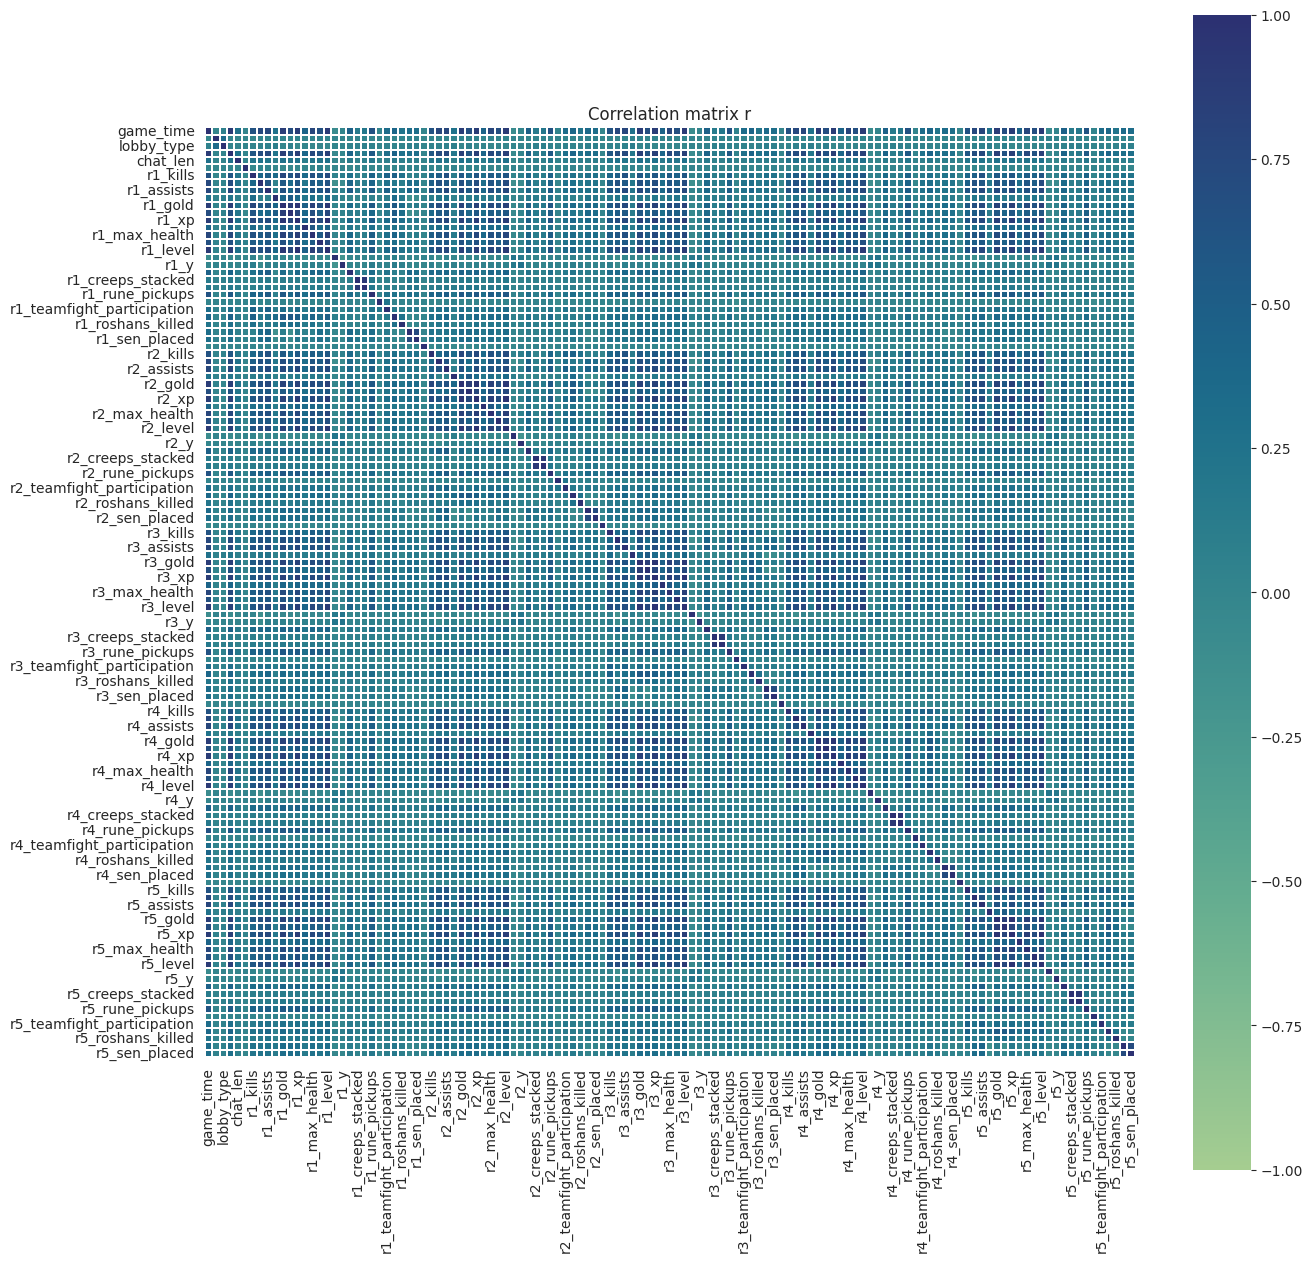

In [307]:
#из визуализации давайте только корреляции глянем (боксплоты и всякое такое нам не сильно поможет, мне кажется)
#т.к. признаков оч много предлагаю сделать так: построить общие признаки+индивидуальные по команде

r_columns = list(df_train_features_extended.columns[0:125])
r_df_train_features_extended = df_train_features_extended[r_columns]
r_correlations = r_df_train_features_extended.corr()

plt.figure(figsize=(15,15))
sns.heatmap(r_correlations, square=True, linewidths=0.25, vmin=-1, vmax=1, cmap="crest")
plt.title("Correlation matrix r")
plt.show();

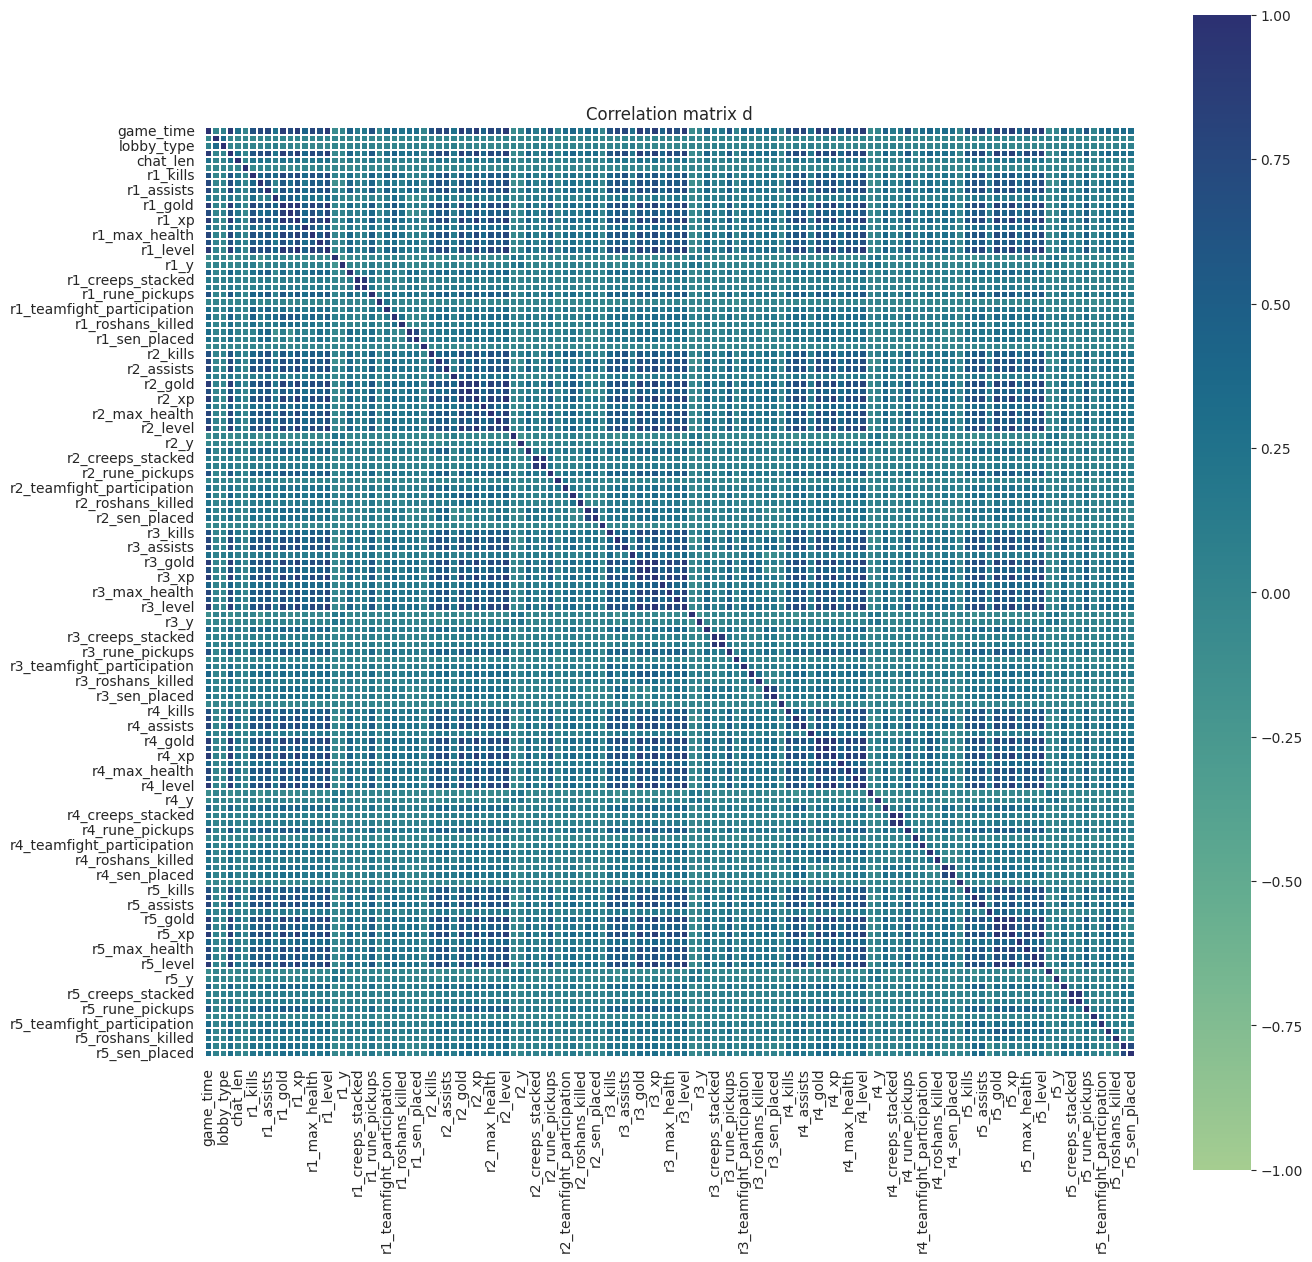

In [308]:
#d
d_columns = list(df_train_features_extended.columns[0:125])
d_df_train_features_extended = df_train_features_extended[d_columns]
d_correlations = d_df_train_features_extended.corr()

plt.figure(figsize=(15,15))
sns.heatmap(d_correlations, square=True, linewidths=0.25, vmin=-1, vmax=1, cmap="crest")
plt.title("Correlation matrix d")
plt.show();

Даже в таком вариате тяжеловато что-то разглядеть, но классно, что у нас как будто фичи типа kills, assists и т.д. бьются по игрокам (в плане для пары игроков аналогичные фичи коррелируют (что называется "командная игра").

Пока ничего дропать не будем (если у нас очень много фичей, то может ансамблю это и хорошо, это может помочь рандомизации предсказаний (а может и не поможет, если индивидуальные модели имеют низкую вероятность).


**Теперь давайте к моделям вернёмся:**

## Кое-что попробуем (назовём "вырубка леса")

Тут бы надо взять уже другую модельку просто, но я на днях наткнулась на [статью на хабре](https://habr.com/ru/articles/767708/) и мне интересно попробовать насколько это сработает. 

Они предлагают улучшить RandomForestClassifier таким образом: когда мы берём ансамбль, то какие-то деревья показывают топ-результат, какие-то дно-результат. И мы уже прошли методы бустинга, когда пытаемся улучшить предсказания плохих моделек, а тут предалают просто убрать плохо-предсказывающие деревья из ансамбля примерно так:

* обучаем ансамбль
* ищем точность на тесте (ну в нашем случае на valid) для каждого отдельного дерева в ансамбле
* оставим только k лучших деревьев в ансамбле

Let's go


In [81]:
#только сначала возьмём наши признаки новые
X_ext = df_train_features_extended.values
y_ext = df_train_targets["radiant_win"].values.astype("int8")
X_train_ext, X_valid_ext, y_train_ext, y_valid_ext = train_test_split(X_ext, y_ext,
                                                                      test_size=0.3,
                                                                      random_state=SEED)

In [83]:
X_ext.shape

(31698, 254)

In [102]:
model = RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)
model.fit(X_train_ext, y_train_ext)

RandomForestClassifier(max_depth=7, n_estimators=300, n_jobs=-1,
                       random_state=10801)

In [103]:
print("ROC-AUC score на отложенной части для исходной модельки:", roc_auc_score(y_valid_ext, model.predict_proba(X_valid_ext)[:, 1]))
#пока всё как было

ROC-AUC score на отложенной части для исходной модельки: 0.7876884023185358


In [104]:
#мы перебираем все деревья и вычисляем их точность тестирования
model_rauc = []

for idx, tree in enumerate(model.estimators_):

    score = roc_auc_score(y_valid_ext, tree.predict_proba(X_valid_ext)[:, 1])
    model_rauc.append([idx, score])
    
model_rauc = np.array(model_rauc)

In [105]:
#Теперь мы должны переставить модели дерева решений в списке model.estimators_ в порядке убывания точности тестирования
sorted_indices = np.argsort(model_rauc[:, 1])[::-1]
model_ids = model_rauc[sorted_indices][:,0].astype(int)
model_ids[0:5]#лучшее дерево 140ое

array([140, 184, 209,  93, 214])

In [106]:
# а теперь мы просто переставляем их внутри модели как отсортировали
model.estimators_ = np.array(model.estimators_)[model_ids].tolist()

In [107]:
%%time
#Всё. Копируем нашу исходную модельку в small_model. 
#На каждой итерации мы устанавливаем деревья small_model на первые “k” деревьев базовой модели.
#И в итоге оцениваем small_model только с помощью “k” деревьев.
import copy
result = []
total_models = len(model.estimators_) 
for i in range(2, total_models):
    
    small_model = copy.deepcopy(model)
    
    small_model.estimators_ = model.estimators_[:i]
    result.append([i, small_model.score(X_valid_ext, y_valid_ext)])
    
result = np.array(result)

CPU times: user 1min 37s, sys: 4.92 s, total: 1min 42s
Wall time: 57.1 s


In [108]:
#глянем лучший k
max_index = np.argmax(result[:, 1])
max_index

37

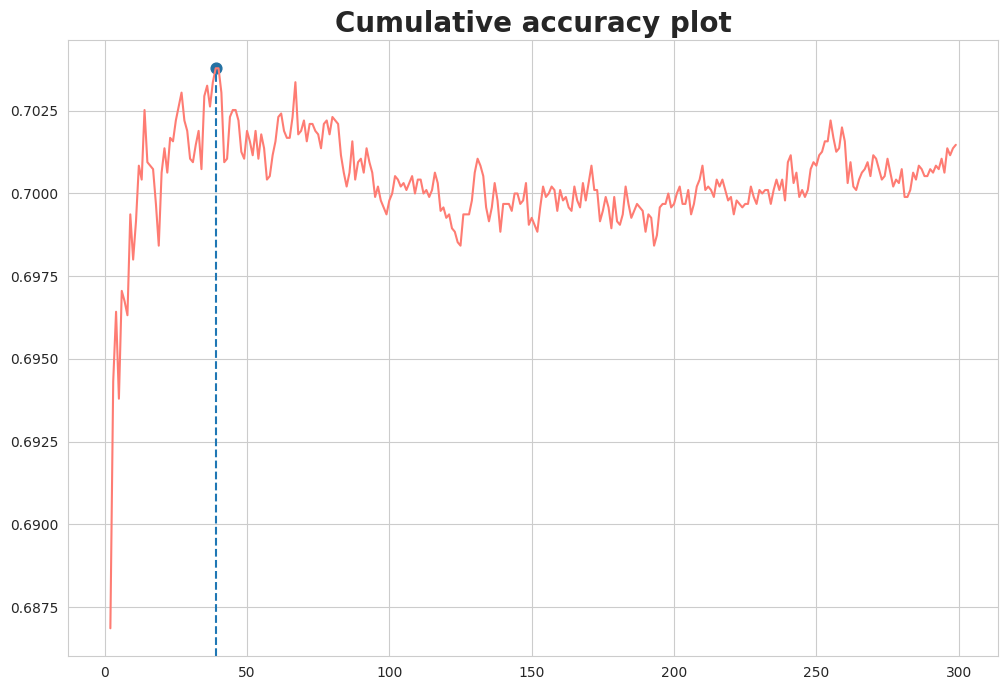

In [110]:
colors = ['#fe7c73', '#2471A3']
fig, ax = plt.subplots()
ax.plot(result[:, 0], result[:, 1], c = colors[0])
ax.axvline(x=result[max_index][0], ymax=0.95, ls = "--")
plt.scatter([result[max_index][0],], [result[max_index][1],], zorder=0, s=60, c = colors[1])

ax.set_title("Cumulative accuracy plot", fontsize = 20, fontweight = "bold")
plt.show()

In [111]:
#теперь берём модельку с лучшим k
small_model = copy.deepcopy(model)
small_model.estimators_ = model.estimators_[:int(result[max_index][0])]

ROC-AUC score на отложенной части для маленькой модельки: 0.7861309931193969


In [113]:
cv_scores_extended_sm = cross_val_score(small_model, df_train_features_extended.values, y,
                                     cv=cv, scoring="roc_auc", n_jobs=-1)

In [115]:
print(f"ROC-AUC на кросс-валидации для новых признаков для маленькой модельки: {cv_scores_extended_sm.mean()}")

ROC-AUC на кросс-валидации для новых признаков для маленькой модельки: 0.7871911791201274


В общем не особо сработало, но прикольно. Вообще это же не только для улучшения качества применимо, но и для быстроты обучения. Но нам не повезло тут (но там и на плоте видно, что это скорее флуктуации, нежели рил норм модель). Надо двигаться дальше.

# Давайте попробуем другую модельку: catboost

*Почему catboost: он хорош для категориальных признаков, с которыми мы ещё не работали здесь + неплох для большого количества данных, что тоже наш случай.*

In [116]:
from catboost import CatBoostClassifier, Pool, cv

In [117]:
df_train_features_extended.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 31698 entries, b9c57c450ce74a2af79c9ce96fac144d to e2ca68ac1a6847f4a37f6c9c8ee8695b
Data columns (total 254 columns):
 #    Column                      Dtype  
---   ------                      -----  
 0    game_time                   int64  
 1    game_mode                   int64  
 2    lobby_type                  int64  
 3    objectives_len              int64  
 4    chat_len                    int64  
 5    r1_hero_id                  int64  
 6    r1_kills                    int64  
 7    r1_deaths                   int64  
 8    r1_assists                  int64  
 9    r1_denies                   int64  
 10   r1_gold                     int64  
 11   r1_lh                       int64  
 12   r1_xp                       int64  
 13   r1_health                   int64  
 14   r1_max_health               int64  
 15   r1_max_mana                 float64
 16   r1_level                    int64  
 17   r1_x                        int64

In [125]:
#сделаем по канону со специальным объектом Pool для представления данных (хотя может это и не канон, но выглядит солиднее и не надо миллион раз прописывать иксы, игреки...)
train_data = Pool(data=X_train_ext, label=y_train_ext)

In [126]:
%%time
#начнём с базы (дефолтные параметры)
cat = CatBoostClassifier(random_seed=SEED, verbose=False)
cat.fit(train_data)

CPU times: user 2min 21s, sys: 5.12 s, total: 2min 27s
Wall time: 38.9 s


In [135]:
print("ROC-AUC score для базового catboost (не кросс-валидация):", roc_auc_score(y_valid, cat.predict_proba(X_valid_ext)[:, 1]))
#о, 0,8 выбили. Продолжаем

ROC-AUC score для базового catboost (не кросс-валидация): 0.8003171807871058


In [151]:
#будем держать перед глазами какие параметры у нас в базовой
cat.get_all_params()#ну будем ориентироваться на что-то наиболее понятное: 'iterations': 1000, 'l2_leaf_reg': 3, 'depth': 6, 'min_data_in_leaf': 1, 'learning_rate': 0.038701001554727554, 'max_leaves': 64

{'nan_mode': 'Min',
 'eval_metric': 'Logloss',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': False,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': False,
 'class_names': [0, 1],
 'random_seed': 10801,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,


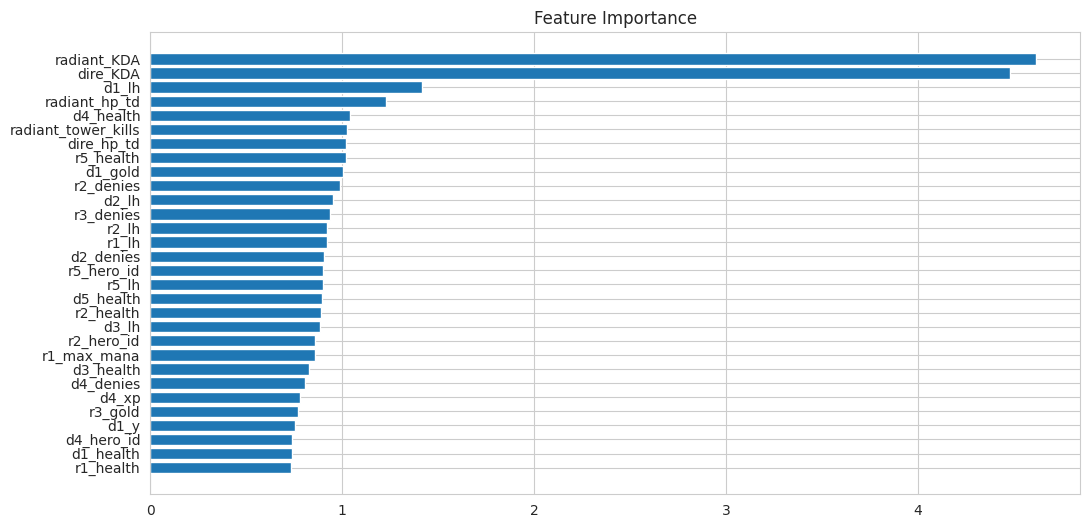

In [163]:
#посмотрим какие признаки важны (топ-30)
feature_importance = cat.feature_importances_
sorted_idx = np.argsort(feature_importance)[-31:-1]
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(df_train_features_extended.columns)[sorted_idx])
plt.title('Feature Importance');
#у нас опять KDA (что логично выглядит), башни, hero_id(что тоже ожидаемо и логично), даже мой динамический hp_td есть (но это лол)

In [154]:
%%time
#что там с cv
params = {
    'loss_function': 'Logloss',
    'iterations': 1000,
    'custom_loss': 'AUC',
    'random_seed': SEED,
    'learning_rate': 0.3
}

cv_results = cv(
    params=params,
    pool=train_data,
    fold_count=5,
    shuffle=True,
    partition_random_seed=SEED,
    stratified=True, 
    verbose=False
)
cv_results

Training on fold [0/5]

bestTest = 0.5395545653
bestIteration = 41

Training on fold [1/5]

bestTest = 0.5569411418
bestIteration = 51

Training on fold [2/5]

bestTest = 0.5327780018
bestIteration = 52

Training on fold [3/5]

bestTest = 0.5345682383
bestIteration = 43

Training on fold [4/5]

bestTest = 0.550027709
bestIteration = 24

CPU times: user 11min 32s, sys: 33.4 s, total: 12min 5s
Wall time: 3min 26s


,iterations,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std,test-AUC-mean,test-AUC-std
0,0,0.629748,0.003824,0.628795,0.001808,0.753838,0.009981
1,1,0.597873,0.003823,0.595987,0.002993,0.764543,0.007994
2,2,0.579229,0.004276,0.576682,0.002218,0.770938,0.009605
3,3,0.569205,0.004982,0.564984,0.002017,0.773937,0.008933
4,4,0.563178,0.005834,0.557838,0.002285,0.776434,0.008422
...,...,...,...,...,...,...,...
995,995,0.669103,0.030099,0.032421,0.001292,0.786766,0.010274
996,996,0.669267,0.030158,0.032347,0.001292,0.786713,0.010292
997,997,0.669469,0.030186,0.032269,0.001312,0.786711,0.010325
998,998,0.669879,0.030292,0.032180,0.001325,0.786641,0.010406


In [165]:
cv_results['test-AUC-mean'].max()#всё плохо

0.7903986737171425

**Вернёмся к категориальным признакам, которые мы выбрали в разделе EDA**

In [257]:
cat_features=[1, 2, 5, 29, 53, 77, 101, 125, 149, 173, 197, 221]
X_train_ext_df = pd.DataFrame(X_train_ext, columns=df_train_features_extended.columns)
X_train_ext_df[X_train_ext_df.columns[cat_features]] = X_train_ext_df[X_train_ext_df.columns[cat_features]].astype('int')
train_data_cat = Pool(data=X_train_ext_df, label=y_train_ext, cat_features=cat_features)#добавим обязательно сюда

In [258]:
%%time

cat_cat = CatBoostClassifier(random_seed=SEED, verbose=False)
cat_cat.fit(train_data_cat)

CPU times: user 5min 36s, sys: 42.1 s, total: 6min 18s
Wall time: 1min 50s


In [259]:
X_valid_ext_df = pd.DataFrame(X_valid_ext, columns=df_train_features_extended.columns)
X_valid_ext_df[X_valid_ext_df.columns[cat_features]] = X_valid_ext_df[X_valid_ext_df.columns[cat_features]].astype('int')

In [260]:
print("ROC-AUC score для базового catboost (не кросс-валидация):", roc_auc_score(y_valid, cat_cat.predict_proba(X_valid_ext_df)[:, 1]))
#ну прям на капельку лучше да

ROC-AUC score для базового catboost (не кросс-валидация): 0.8036078460799936


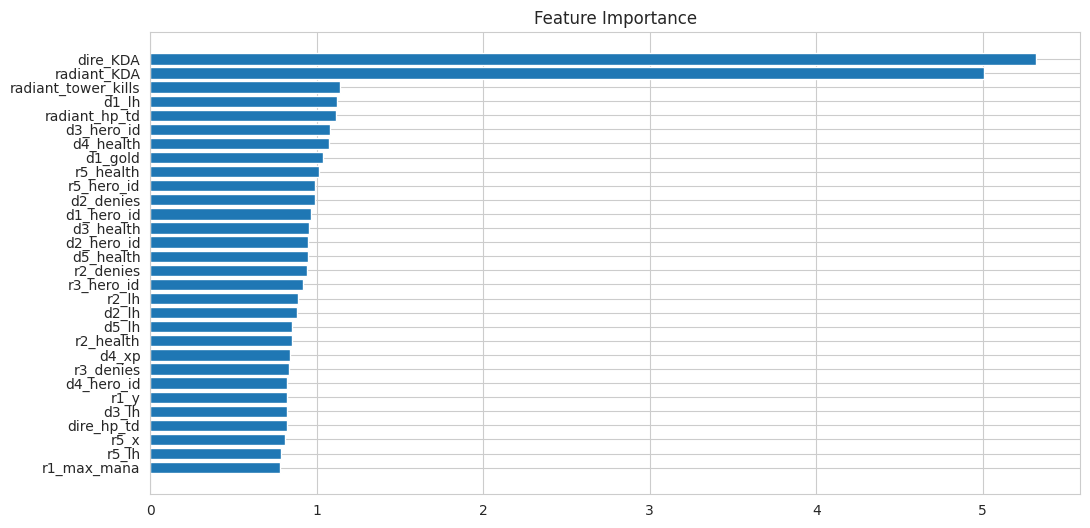

In [262]:
#посмотрим какие признаки важны (топ-30)
feature_importance = cat_cat.feature_importances_
sorted_idx = np.argsort(feature_importance)[-31:-1]
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(df_train_features_extended.columns)[sorted_idx])
plt.title('Feature Importance');
#не сильно что-то поменялось

**Давайте запускать GridSearch**

In [309]:
 from sklearn.model_selection import GridSearchCV

In [ ]:
%%time
cat = CatBoostClassifier()
space_cat = {
    'iterations': [100, 500, 1000],
    'learning_rate': [0.01, 0.1, 1],
    'depth': [2, 3, 6],
    'random_state': [SEED]   
}

grid_search = GridSearchCV(
    estimator=cat,
    param_grid=space_cat,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=1
)

grid_search.fit(df_train_features_extended.values, y)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
0:	learn: 0.6911640	total: 102ms	remaining: 10.1s
1:	learn: 0.6891797	total: 144ms	remaining: 7.08s
2:	learn: 0.6872268	total: 191ms	remaining: 6.16s
3:	learn: 0.6853032	total: 247ms	remaining: 5.92s
4:	learn: 0.6834043	total: 288ms	remaining: 5.47s
5:	learn: 0.6815960	total: 335ms	remaining: 5.25s
6:	learn: 0.6797651	total: 378ms	remaining: 5.02s
7:	learn: 0.6780237	total: 423ms	remaining: 4.87s
8:	learn: 0.6762621	total: 493ms	remaining: 4.98s
9:	learn: 0.6745561	total: 543ms	remaining: 4.88s
10:	learn: 0.6729162	total: 588ms	remaining: 4.76s
11:	learn: 0.6712945	total: 636ms	remaining: 4.66s
12:	learn: 0.6696877	total: 670ms	remaining: 4.48s
13:	learn: 0.6680551	total: 708ms	remaining: 4.35s
14:	learn: 0.6664985	total: 762ms	remaining: 4.32s
15:	learn: 0.6649798	total: 840ms	remaining: 4.41s
16:	learn: 0.6634435	total: 906ms	remaining: 4.42s
17:	learn: 0.6619062	total: 974ms	remaining: 4.44s
18:	learn: 0.6603688	total: 1.

In [ ]:
print(grid_search.best_params_)

In [ ]:
#лучшая
cat_best = CatBoostClassifier(depth=6, iterations=500, learning_rate=0.1, random_state=SEED)
cat_best.fit(df_train_features_extended.values, y)
X_test = df_test_features_extended.values
y_test_pred = cat_best.predict_proba(X_test)[:, 1]

In [ ]:
#сама посылка
df_submission_extended = pd.DataFrame({"radiant_win_prob": y_test_pred},
                                 index=df_test_features_extended.index)

submission_filename = "submission_{}.csv".format(
    datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
df_submission_extended.to_csv(submission_filename)
print("Файл посылки сохранен, как: {}".format(submission_filename))



# Итог

| № | описание                                                | модель                                                                                                    | кол-во фичей | ~метрика на cv (не на cv) | на каггле | коммент                                                               |   |
|---|---------------------------------------------------------|-----------------------------------------------------------------------------------------------------------|--------------|---------------------------|-----------|-----------------------------------------------------------------------|---|
| 1 | авторские фичи (наша 1ая модель)                        | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)                       | 245          | ~0.772                    | 0.786     | бейзлайн                                                              |   |
| 2 | добавление вышек (2ая версия модели)                    | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)                       | 248          | ~0.779                    | 0.793     | стало лучше и признак важен                                           |   |
| 3 | +KDA (3я версия модели)'                                | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)                       | 250          | ~0.787                    | na        | стало лучше и признак важен                                           |   |
| 3 | +ability_uses (3я версия модели)'                       | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)                       | 252          | ~0.787                    | na        | не особо изменилось                                                   |   |
| 3 | +xp_td (3я версия модели)'                              | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)                       | 254          | ~0.787                    | 0.797     | не особо изменилось                                                   |   |
| 4 | "вырубка леса"                                          | small_model с k=37 от RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED) | 254          | ~0.787                    | na        | не особо изменилось, но на фича-импортансе видно, что признак юзается |   |
| 5 | catboost дефолтный                                      | CatBoostClassifier(random_seed=SEED, verbose=False)                                                       | 254          | ~(0.800)                  | na        | бустанул                                                              |   |
| 6 | catboost с заданными вручную категориальными признаками | CatBoostClassifier(random_seed=SEED, verbose=False)                                                       | 254          | ~(0.804)                  | na        | бустанул                                                              |   |
| 7 | catboost_best (после гридсёрча)                         | CatBoostClassifier(random_seed=SEED, verbose=False)                                                       | 254          |                           |           |                                                                       |   |